In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,OrdinalEncoder,OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline

In [3]:
df=pd.read_csv('./CSVs/cars.csv')

In [4]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [5]:
count=df.value_counts("brand")

In [6]:
count

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Opel                1
Peugeot             1
Ashok               1
Name: count, dtype: int64

In [7]:
repl=count[count<100].index

In [8]:
repl

Index(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Kia',
       'Ambassador', 'MG', 'Daewoo', 'Opel', 'Peugeot', 'Ashok'],
      dtype='object', name='brand')

In [9]:
df.brand.replace(repl,"Uncommon",inplace=True)

C:\Users\Admi\AppData\Local\Temp\ipykernel_3344\1512167788.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.brand.replace(repl,"Uncommon",inplace=True)


In [10]:
df.brand.value_counts()

brand
Maruti        2448
Hyundai       1415
Mahindra       772
Tata           734
Uncommon       538
Toyota         488
Honda          467
Ford           397
Chevrolet      230
Renault        228
Volkswagen     186
BMW            120
Skoda          105
Name: count, dtype: int64

In [11]:
df.isnull().sum()

brand            0
km_driven        0
fuel             0
owner            0
selling_price    0
dtype: int64

In [12]:
df.describe()

,km_driven,selling_price
count,8.128000e+03,8.128000e+03
mean,6.981951e+04,6.382718e+05
std,5.655055e+04,8.062534e+05
min,1.000000e+00,2.999900e+04
25%,3.500000e+04,2.549990e+05
50%,6.000000e+04,4.500000e+05
75%,9.800000e+04,6.750000e+05
max,2.360457e+06,1.000000e+07


<Axes: xlabel='km_driven', ylabel='fuel'>

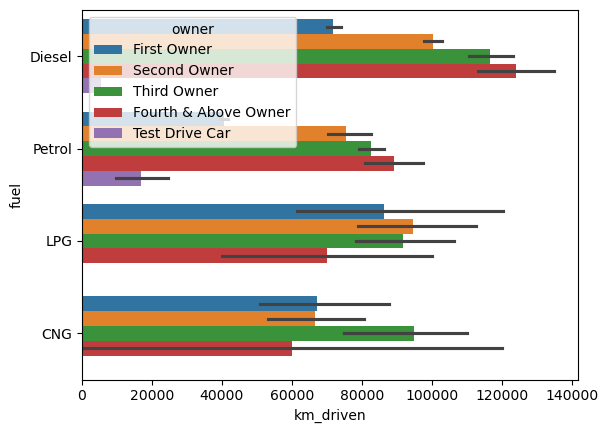

In [13]:

sns.barplot(x=df.km_driven,y=df.fuel,hue=df.owner)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB


In [15]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [113]:
_1_trans=ColumnTransformer([
        ("For_Brand",OneHotEncoder(sparse_output=False,drop="first"),['brand']),
        ("For_Fuel",OneHotEncoder(sparse_output=False,drop="first"),['fuel'])
],remainder="passthrough")

In [114]:
_2_trans=ColumnTransformer([
        ("For_Owner",OrdinalEncoder(categories=[['Fourth & Above Owner','Third Owner', 'Second Owner', 'First Owner','Test Drive Car']]),
         ['remainder__owner']),
],remainder="passthrough")

In [115]:
_3_trans=ColumnTransformer([
        ("Standardize",MinMaxScaler(),['remainder__remainder__selling_price','remainder__remainder__km_driven']),
],remainder="passthrough")

In [116]:
from sklearn import set_config
set_config(display='diagram')

In [117]:
pipe=make_pipeline(_1_trans,_2_trans,_3_trans)

In [118]:
pipe.named_steps['columntransformer-1'].transformers[0]

('For_Brand', OneHotEncoder(drop='first', sparse_output=False), ['brand'])

In [119]:
set_config(transform_output="pandas")

In [120]:
new_df=pipe.fit_transform(df)

In [121]:
new_df.describe()

,Standardize__remainder__remainder__selling_price,Standardize__remainder__remainder__km_driven,remainder__For_Owner__remainder__owner,remainder__remainder__For_Brand__brand_Chevrolet,remainder__remainder__For_Brand__brand_Ford,remainder__remainder__For_Brand__brand_Honda,remainder__remainder__For_Brand__brand_Hyundai,remainder__remainder__For_Brand__brand_Mahindra,remainder__remainder__For_Brand__brand_Maruti,remainder__remainder__For_Brand__brand_Renault,remainder__remainder__For_Brand__brand_Skoda,remainder__remainder__For_Brand__brand_Tata,remainder__remainder__For_Brand__brand_Toyota,remainder__remainder__For_Brand__brand_Uncommon,remainder__remainder__For_Brand__brand_Volkswagen,remainder__remainder__For_Fuel__fuel_Diesel,remainder__remainder__For_Fuel__fuel_LPG,remainder__remainder__For_Fuel__fuel_Petrol
count,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.00000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000
mean,0.061010,0.029578,2.540846,0.028297,0.048844,0.057456,0.17409,0.094980,0.301181,0.028051,0.012918,0.090305,0.060039,0.066191,0.022884,0.541585,0.004675,0.446727
std,0.080868,0.023957,0.717381,0.165831,0.215554,0.232726,0.37921,0.293206,0.458799,0.165129,0.112929,0.286636,0.237574,0.248631,0.149542,0.498298,0.068220,0.497185
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.022568,0.014827,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.042126,0.025418,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.064694,0.041517,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [122]:
new_df

,Standardize__remainder__remainder__selling_price,Standardize__remainder__remainder__km_driven,remainder__For_Owner__remainder__owner,remainder__remainder__For_Brand__brand_Chevrolet,remainder__remainder__For_Brand__brand_Ford,remainder__remainder__For_Brand__brand_Honda,remainder__remainder__For_Brand__brand_Hyundai,remainder__remainder__For_Brand__brand_Mahindra,remainder__remainder__For_Brand__brand_Maruti,remainder__remainder__For_Brand__brand_Renault,remainder__remainder__For_Brand__brand_Skoda,remainder__remainder__For_Brand__brand_Tata,remainder__remainder__For_Brand__brand_Toyota,remainder__remainder__For_Brand__brand_Uncommon,remainder__remainder__For_Brand__brand_Volkswagen,remainder__remainder__For_Fuel__fuel_Diesel,remainder__remainder__For_Fuel__fuel_LPG,remainder__remainder__For_Fuel__fuel_Petrol
0,0.042126,0.061640,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.034102,0.050837,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.012839,0.059310,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.019559,0.053803,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.010030,0.050837,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0.029087,0.046601,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8124,0.010532,0.050414,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8125,0.035306,0.050837,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8126,0.026078,0.010591,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [123]:
from sklearn.linear_model import LinearRegression

In [145]:
x=new_df.drop(columns=['Standardize__remainder__remainder__selling_price'],axis=1)
y=new_df['Standardize__remainder__remainder__selling_price']
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.1)

In [146]:
lr=LinearRegression()

In [147]:
lr.fit(X_train,Y_train)

LinearRegression()

In [148]:
pred=lr.predict(X_test)

In [149]:
pred.shape, Y_test.shape

((813,), (813,))

In [150]:
from sklearn.metrics import confusion_matrix
r2_score(y_true=Y_test,y_pred=pred)


0.6109635496894994